## Class Creation - Data Puller & Baseline Analysis

In [ ]:
# CLASS CREATION - STOCK_DATA_PULLER

!pip install alpaca-py

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from datetime import datetime, timedelta

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

class AlpacaDataPuller:
    '''
    Pulls Stock Data from Alpaca API.
    symbols: List of stock symbols
    api_key: Alpaca account API Key
    secret_key: Alpaca account Secret Key
    bar_size: In Minutes - how long you want each bar - ie open to close length
    '''
    def __init__ (
        self, 
        symbols: list[str], 
        api_key: str,
        secret_key: str,
        timeframe_amount: int = 5,
        timeframe_unit: str = "minute"
    ):

        self.symbols = symbols
        self.api_key = api_key
        self.secret_key = secret_key
        self.timeframe_amount = timeframe_amount
        self.timeframe_unit = timeframe_unit

        # INITIALIZE ALPACA CLIENT
        self.client = StockHistoricalDataClient(
            api_key,
            secret_key
        )

    def get_timeframe(self, amount=None, unit=None):
        """
        Converts amount/unit inputs into an Alpaca TimeFrame object.
        """

        if amount is None:
            amount = self.timeframe_amount

        if unit is None:
            unit = self.timeframe_unit

        unit = unit.lower()

        unit_map = {
            "minute": TimeFrameUnit.Minute,
            "min": TimeFrameUnit.Minute,
            "hour": TimeFrameUnit.Hour,
            "day": TimeFrameUnit.Day,
            "week": TimeFrameUnit.Week,
        }

        if unit not in unit_map:
            raise ValueError("timeframe_unit must be: minute, hour, day, or week")

        return TimeFrame(amount, unit_map[unit])

    # Pulls stock data for a single Symbol
    def pull_symbol_data(self, symbol, start= None, end= None, timeframe_amount = None, timeframe_unit = None):
        '''
        Pulls stock data for given symbol 'XYZ'
        start & end format: (YYYY, MM, DD)
        If start/ end blank, defaults to last 10 years
        '''

        # Checks for start and end input - 10 years as default
        if end is None:
            end_date = datetime.today()
        else:
            end_date = datetime(*end)

        if start is None:
            start_date = end_date - timedelta(days=365 * 10)
        else:
            start_date = datetime(*start)

        request = StockBarsRequest(
        symbol_or_symbols=symbol,
        timeframe=self.get_timeframe(timeframe_amount, timeframe_unit),
        start=start_date,
        end=end_date,
        )

        bars = self.client.get_stock_bars(request)
        df = bars.df
        return df


    # Uses previous method to combine multiple symbols into a dictionary
    def pull_symbols_data(self, symbols=None, start=None, end=None, timeframe_amount = None, timeframe_unit = None):
        '''
        Pulls data for multiple symbols (list) into a dictionary
        '''
        # If NO symbols are passed, default to class symbols
        if symbols is None:
            symbols = self.symbols

        data = {}

        for symbol in symbols:
            data[symbol] = self.pull_symbol_data(symbol,start,end, timeframe_amount, timeframe_unit)

        return data


class BaselineAnalysis:
    """
    Runs baseline stock target analysis for multiclass ML classification.

    Creates 5 target classes based on future returns:

        0 = worst 20% of returns
        1 = 20th-40th percentile
        2 = 40th-60th percentile
        3 = 60th-80th percentile
        4 = best 20% of returns

    df: OHLCV dataframe from AlpacaDataPuller.
        Must contain a 'close' column by default.

    horizon:
        Number of periods ahead to predict.
        horizon=1 means next bar / next day return.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        price_col: str = "close",
        horizon: int = 1,
        n_classes: int = 5
    ):
        self.df = df.copy()
        self.price_col = price_col
        self.horizon = horizon
        self.n_classes = n_classes

        self.past_return_col = "past_return_1"
        self.target_return_col = f"future_return_{horizon}"
        self.target_class_col = f"target_class_{n_classes}q"

        self.bin_edges = None
        self.class_summary = None

        self._validate_inputs()

    def _validate_inputs(self):
        """
        Checks that the dataframe has the required columns.
        """

        if self.price_col not in self.df.columns:
            raise ValueError(f"Dataframe must contain '{self.price_col}' column.")

        if self.horizon < 1:
            raise ValueError("horizon must be >= 1.")

        if self.n_classes < 2:
            raise ValueError("n_classes must be >= 2.")

    def calculate_returns(self):
        """
        Adds past return and future target return columns.

        past_return_1:
            Previous period return, useful as a feature.

        future_return_horizon:
            Future return from current close to close horizon periods ahead.
            This is the value used to create target classes.
        """

        close = self.df[self.price_col]

        self.df[self.past_return_col] = close.pct_change()

        self.df[self.target_return_col] = (
            close.shift(-self.horizon) / close - 1
        )

        return self.df

    def create_quantile_classes(self):
        """
        Creates target classes using equal-frequency quantile bins.

        For n_classes=5, this creates 20% buckets.
        """

        if self.target_return_col not in self.df.columns:
            self.calculate_returns()

        target_returns = self.df[self.target_return_col].dropna()

        class_codes, bin_edges = pd.qcut(
            target_returns,
            q=self.n_classes,
            labels=False,
            retbins=True,
            duplicates="drop"
        )

        actual_classes = len(bin_edges) - 1

        if actual_classes != self.n_classes:
            raise ValueError(
                f"Could only create {actual_classes} classes instead of "
                f"{self.n_classes}. This usually happens when too many "
                f"target returns have identical values."
            )

        self.bin_edges = bin_edges

        self.df[self.target_class_col] = pd.Series(
            pd.NA,
            index=self.df.index,
            dtype="Int64"
        )

        self.df.loc[class_codes.index, self.target_class_col] = (
            class_codes.astype("Int64")
        )

        return self.df

    def summarize_classes(self):
        """
        Summarizes the return range and count for each target class.
        """

        if self.target_class_col not in self.df.columns:
            self.create_quantile_classes()

        summary = (
            self.df
            .dropna(subset=[self.target_class_col])
            .groupby(self.target_class_col)[self.target_return_col]
            .agg(
                count="count",
                min_return="min",
                max_return="max",
                mean_return="mean",
                median_return="median"
            )
            .reset_index()
        )

        summary["class_name"] = summary[self.target_class_col].map(
            self.get_class_labels()
        )

        total = summary["count"].sum()
        summary["percent_of_data"] = summary["count"] / total

        self.class_summary = summary

        return summary

    def get_class_labels(self):
        """
        Returns readable class labels.
        """

        if self.n_classes == 5:
            return {
                0: "Worst 20%",
                1: "20-40%",
                2: "40-60%",
                3: "60-80%",
                4: "Best 20%"
            }

        return {
            i: f"Class {i}"
            for i in range(self.n_classes)
        }

    def get_bin_edges(self):
        """
        Returns the quantile boundaries used for class creation.
        """

        if self.bin_edges is None:
            self.create_quantile_classes()

        return self.bin_edges

    def data_explorer(self, bins: int = 50):
        """
        Creates a histogram of future returns and shows class boundaries.
        """

        if self.target_return_col not in self.df.columns:
            self.calculate_returns()

        if self.bin_edges is None:
            self.create_quantile_classes()

        target_returns = self.df[self.target_return_col].dropna()

        lower = target_returns.quantile(0.02)
        upper = target_returns.quantile(0.98)

        plt.figure(figsize=(10, 5))
        plt.hist(target_returns, bins=75, range=(lower, upper))
        plt.xlim(lower, upper)

        for edge in self.bin_edges[1:-1]:
            if lower <= edge <= upper:
                plt.axvline(edge, linestyle="--")

        plt.title(f"Distribution of {self.horizon}-Period Future Returns")
        plt.xlabel("Future Return")
        plt.ylabel("Frequency")
        plt.show()

    def run_analysis(self):
        """
        Runs the full baseline analysis.
        """

        self.calculate_returns()
        self.create_quantile_classes()
        summary = self.summarize_classes()

        return self.df, summary


## SPY Example using AlpacaDataPuller & BaselineAnalysis

In [70]:
## AplacaDataPuller

# REQUIRED INPUTS
API_KEY = "PKEN63LDIFPD43FZN5JQXXXHXV"
SECRET_KEY = "3pmEQxuC9R5vGL4y6YSfDMWq9fgSM8nBZae8QGHyoE3C"
SYMBOLS = ['SPY']

# PULL SPY HISTORICALS INTO DICTIONARY BY TIME UNIT

puller_hrly = AlpacaDataPuller(SYMBOLS,API_KEY,SECRET_KEY, timeframe_amount=1, timeframe_unit="hour")

puller_daily = AlpacaDataPuller(SYMBOLS,API_KEY,SECRET_KEY, timeframe_amount=1, timeframe_unit="day")

puller_weekly = AlpacaDataPuller(SYMBOLS,API_KEY,SECRET_KEY, timeframe_amount=1, timeframe_unit="week")

SPY_dict = {
    'hourly': puller_hrly.pull_symbols_data(),
    'daily': puller_daily.pull_symbols_data(),
    'weekly': puller_weekly.pull_symbols_data()
}


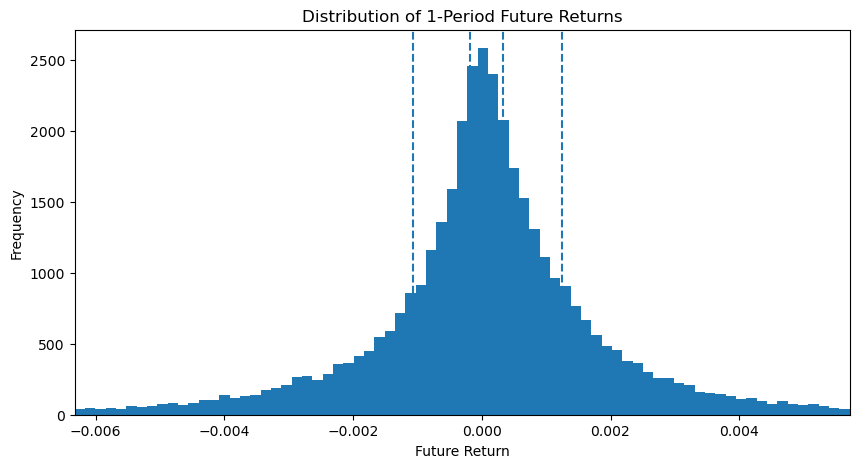

                                   close  past_return_1  future_return_1  \
symbol timestamp                                                           
SPY    2016-06-22 16:00:00+00:00  208.62            NaN         0.000048   
       2016-06-22 17:00:00+00:00  208.63       0.000048        -0.000719   
       2016-06-22 18:00:00+00:00  208.48      -0.000719        -0.002063   
       2016-06-22 19:00:00+00:00  208.05      -0.002063         0.000192   
       2016-06-22 20:00:00+00:00  208.09       0.000192         0.002835   

                                  target_class_5q  
symbol timestamp                                   
SPY    2016-06-22 16:00:00+00:00                2  
       2016-06-22 17:00:00+00:00                1  
       2016-06-22 18:00:00+00:00                0  
       2016-06-22 19:00:00+00:00                2  
       2016-06-22 20:00:00+00:00                4  


,target_class_5q,count,min_return,max_return,mean_return,median_return,class_name,percent_of_data
0,0,7904,-0.084579,-0.001074,-0.003249,-0.002274,Worst 20%,0.2
1,1,7904,-0.001074,-0.000184,-0.000553,-0.000517,20-40%,0.2
2,2,7904,-0.000184,0.000333,0.000068,0.000067,40-60%,0.2
3,3,7904,0.000333,0.001253,0.000728,0.000700,60-80%,0.2
4,4,7904,0.001253,0.067179,0.003188,0.002314,Best 20%,0.2


In [71]:
## BASELINE ANALYSIS - Hourly

df_hourly= SPY_dict["hourly"]["SPY"]
hourly_baseline = BaselineAnalysis(df_hourly, price_col="close", horizon=1)

df_with_targets, summary = hourly_baseline.run_analysis()

hourly_baseline.data_explorer()

print(df_with_targets[["close", "past_return_1", "future_return_1", "target_class_5q"]].head())

summary

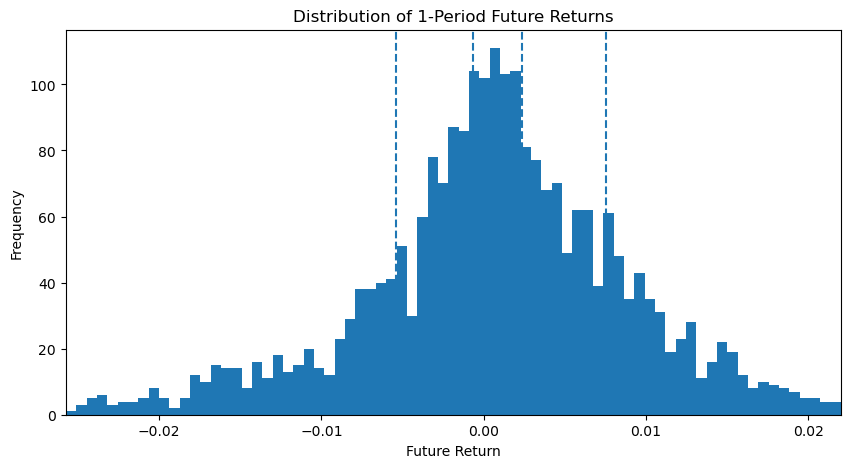

                                     close  past_return_1  future_return_1  \
symbol timestamp                                                             
SPY    2016-06-22 04:00:00+00:00  208.1000            NaN         0.013023   
       2016-06-23 04:00:00+00:00  210.8100       0.013023        -0.035897   
       2016-06-24 04:00:00+00:00  203.2425      -0.035897        -0.017922   
       2016-06-27 04:00:00+00:00  199.6000      -0.017922         0.018035   
       2016-06-28 04:00:00+00:00  203.1997       0.018035         0.017029   

                                  target_class_5q  
symbol timestamp                                   
SPY    2016-06-22 04:00:00+00:00                4  
       2016-06-23 04:00:00+00:00                0  
       2016-06-24 04:00:00+00:00                0  
       2016-06-27 04:00:00+00:00                4  
       2016-06-28 04:00:00+00:00                4  


,target_class_5q,count,min_return,max_return,mean_return,median_return,class_name,percent_of_data
0,0,503,-0.107828,-0.005387,-0.014122,-0.010998,Worst 20%,0.200319
1,1,502,-0.005354,-0.000662,-0.002661,-0.002539,20-40%,0.199920
2,2,502,-0.000659,0.002366,0.000837,0.000755,40-60%,0.199920
3,3,502,0.002378,0.007506,0.004721,0.004586,60-80%,0.199920
4,4,502,0.007528,0.105019,0.014113,0.011597,Best 20%,0.199920


In [64]:
## BASELINE ANALYSIS - Daily

df_daily= SPY_dict["daily"]["SPY"]
daily_baseline = BaselineAnalysis(df_daily, price_col="close", horizon=1)

df_with_targets, summary = daily_baseline.run_analysis()

daily_baseline.data_explorer()

print(df_with_targets[["close", "past_return_1", "future_return_1", "target_class_5q"]].head())

summary

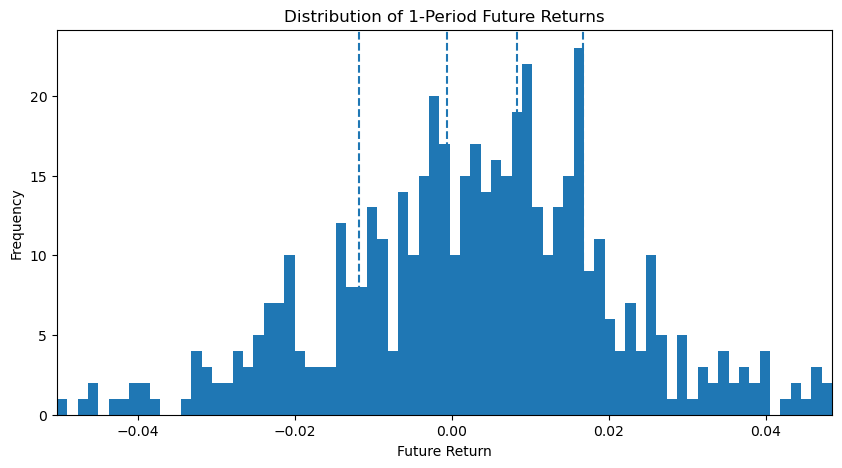

                                     close  past_return_1  future_return_1  \
symbol timestamp                                                             
SPY    2016-06-27 04:00:00+00:00  209.9208            NaN         0.013001   
       2016-07-04 04:00:00+00:00  212.6500       0.013001         0.014954   
       2016-07-11 04:00:00+00:00  215.8300       0.014954         0.006533   
       2016-07-18 04:00:00+00:00  217.2400       0.006533        -0.000552   
       2016-07-25 04:00:00+00:00  217.1200      -0.000552         0.004882   

                                  target_class_5q  
symbol timestamp                                   
SPY    2016-06-27 04:00:00+00:00                3  
       2016-07-04 04:00:00+00:00                3  
       2016-07-11 04:00:00+00:00                2  
       2016-07-18 04:00:00+00:00                2  
       2016-07-25 04:00:00+00:00                2  


,target_class_5q,count,min_return,max_return,mean_return,median_return,class_name,percent_of_data
0,0,104,-0.150999,-0.012092,-0.029306,-0.022927,Worst 20%,0.2
1,1,104,-0.011812,-0.000630,-0.005598,-0.005012,20-40%,0.2
2,2,104,-0.000552,0.008221,0.003958,0.003925,40-60%,0.2
3,3,104,0.008336,0.016689,0.012587,0.012573,60-80%,0.2
4,4,104,0.016696,0.122081,0.031997,0.026159,Best 20%,0.2


In [65]:
## BASELINE ANALYSIS - Weekly

df_weekly = SPY_dict["weekly"]["SPY"]
weekly_baseline = BaselineAnalysis(df_weekly, price_col="close", horizon=1)

df_with_targets, summary = weekly_baseline.run_analysis()

weekly_baseline.data_explorer()

print(df_with_targets[["close", "past_return_1", "future_return_1", "target_class_5q"]].head())

summary

## EDA

In [72]:
## AplacaDataPuller

# REQUIRED INPUTS
API_KEY = "PKEN63LDIFPD43FZN5JQXXXHXV"
SECRET_KEY = "3pmEQxuC9R5vGL4y6YSfDMWq9fgSM8nBZae8QGHyoE3C"
SYMBOLS = ['SPY', 'NVDA', 'MU', 'TSLA']

# PULL SPY HISTORICALS INTO DICTIONARY BY TIME UNIT

puller_hrly = AlpacaDataPuller(SYMBOLS,API_KEY,SECRET_KEY, timeframe_amount=1, timeframe_unit="hour")

puller_daily = AlpacaDataPuller(SYMBOLS,API_KEY,SECRET_KEY, timeframe_amount=1, timeframe_unit="day")

puller_weekly = AlpacaDataPuller(SYMBOLS,API_KEY,SECRET_KEY, timeframe_amount=1, timeframe_unit="week")

SYMBOLS_dict = {
    'hourly': puller_hrly.pull_symbols_data(),
    'daily': puller_daily.pull_symbols_data(),
    'weekly': puller_weekly.pull_symbols_data()
}

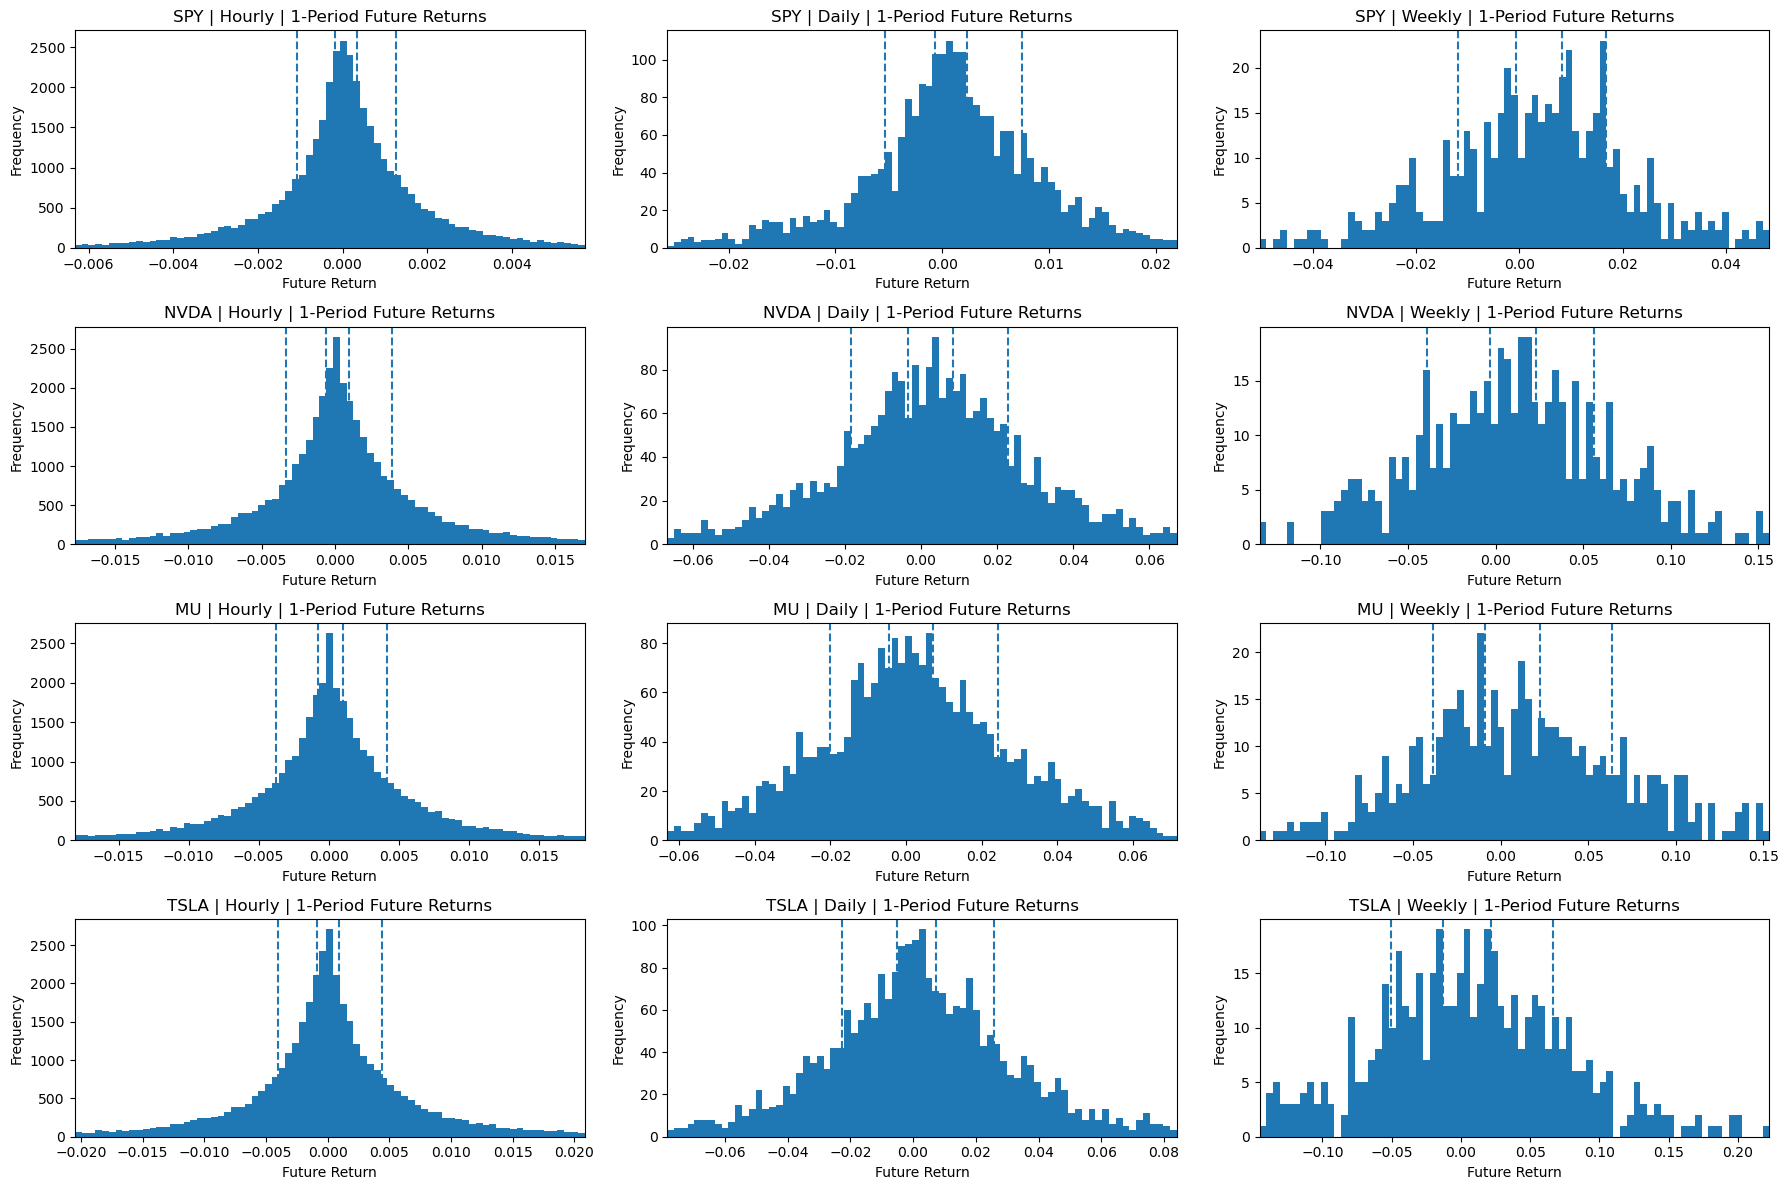

In [ ]:
# Creating a 4x3 Histogram Plot

timeframes = ["hourly", "daily", "weekly"]

plt.figure(figsize=(18, 12))

for r, symbol in enumerate(SYMBOLS):
    for c, timeframe in enumerate(timeframes):

        ax = plt.subplot(4, 3, r * 3 + c + 1)

        baseline = BaselineAnalysis(SYMBOLS_dict[timeframe][symbol])
        baseline.run_analysis()

        returns = baseline.df[baseline.target_return_col].dropna()
        lower, upper = returns.quantile([0.02, 0.98])

        ax.hist(returns, bins=75, range=(lower, upper))
        ax.set_xlim(lower, upper)

        for edge in baseline.bin_edges[1:-1]:
            if lower <= edge <= upper:
                ax.axvline(edge, linestyle="--")

        ax.set_title(f"{symbol} | {timeframe.capitalize()} | 1-Period Future Returns")
        ax.set_xlabel("Future Return")
        ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()